In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import xgboost as xgb

In [2]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [3]:
window_sizes = [5,10,20,30,40]

data_dir = Path("../data/processed/windows_no_leak")

results = []

In [4]:
for w in window_sizes:

    print(f"\nWindow size: {w}")

    data = np.load(data_dir / f"window_{w}.npz")

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    pred_lr = lr.predict(X_test)
    lr_rmse = rmse(y_test, pred_lr)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred_rf = rf.predict(X_test)
    rf_rmse = rmse(y_test, pred_rf)

    # XGBoost
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    pred_xgb = xgb_model.predict(X_test)
    xgb_rmse = rmse(y_test, pred_xgb)

    results.append({
        "window": w,
        "LinearRegression": lr_rmse,
        "RandomForest": rf_rmse,
        "XGBoost": xgb_rmse
    })


Window size: 5

Window size: 10

Window size: 20

Window size: 30

Window size: 40


In [5]:
results_df = pd.DataFrame(results)

results_df

,window,LinearRegression,RandomForest,XGBoost
0,5,19.862824,16.289413,16.130162
1,10,19.333173,16.345871,15.979949
2,20,17.238003,16.392248,14.710071
3,30,15.944954,16.154213,13.665453
4,40,15.153701,15.824786,12.889876


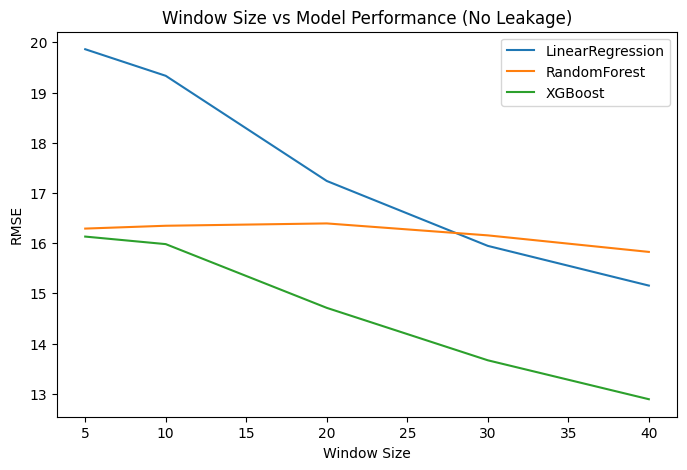

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results_df["window"], results_df["LinearRegression"], label="LinearRegression")
plt.plot(results_df["window"], results_df["RandomForest"], label="RandomForest")
plt.plot(results_df["window"], results_df["XGBoost"], label="XGBoost")

plt.xlabel("Window Size")
plt.ylabel("RMSE")
plt.title("Window Size vs Model Performance (No Leakage)")

plt.legend()

plt.show()